In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
load_dotenv()

True

In [3]:
class SubState(TypedDict):
    inputed_text: str
    translated_text: str

In [4]:
subgraph_llm = ChatOpenAI()

In [5]:
def translate_text(state: SubState):
    prompt = f"""Translate the following text to Urdu: Keep it natural and clear. Do not add extra Content
Text:
{state['inputed_text']}

""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content
    state['translated_text'] = translated_text
    return state

In [6]:
sub_graph_builder = StateGraph(SubState)

sub_graph_builder.add_node('translate_text',translate_text)
sub_graph_builder.add_edge(START, 'translate_text')
sub_graph_builder.add_edge('translate_text', END)

subgraph = sub_graph_builder.compile()

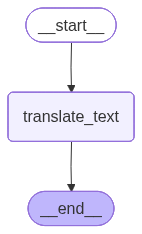

In [7]:
subgraph

In [8]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_urdu: str

In [9]:
parent_llm = ChatOpenAI()

In [10]:
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(f"You are the helpful assistant. Answer clearly. \n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [11]:
def translate_answer(state: ParentState):
    result = subgraph.invoke({'inputed_text': state['answer_eng']})
    return {'answer_urdu': result['translated_text']}

In [12]:
parent_graph_builder = StateGraph(ParentState)

parent_graph_builder.add_node('generate_answer', generate_answer)
parent_graph_builder.add_node('translate_answer', translate_answer)

parent_graph_builder.add_edge(START, 'generate_answer')
parent_graph_builder.add_edge('generate_answer', 'translate_answer')
parent_graph_builder.add_edge('translate_answer', END)

parent_graph = parent_graph_builder.compile()

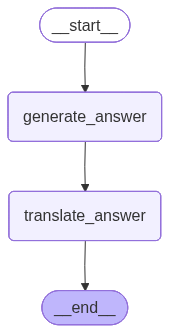

In [13]:
parent_graph

In [14]:
parent_graph.invoke({'question': 'What is quantum physics?'})

{'question': 'What is quantum physics?',
 'answer_eng': 'Quantum physics is a branch of physics that describes the behavior of particles at a very small scale, such as atoms and subatomic particles. It involves concepts such as quantization, wave-particle duality, and superposition, and is essential for understanding the fundamental laws governing the universe at a microscopic level.',
 'answer_urdu': 'یہ ایک طبعیات کی شاخ ہے جو ذرات کی رویہ نماکی کا تفصیلی وضاحت فراہم کرتی ہے، جیسے کہ ایٹم اور ذرات۔ اس میں کوانٹائزیشن، لہر-ذرہ دوہراپن اور سپرپوزیشن جیسے تصورات شامل ہیں، اور یہ ذریعہ فہم کرنے کے لیے ضروری ہے جو کائنات کے بنیادی قوانین کو ناپسند کرتی ہے ایک نہایت چھوٹے سطح پر۔'}